<a href="https://colab.research.google.com/github/ricardo-sallin-pos/fase1-ecommerce-nps-eda/blob/main/Ecommerce_NPS_Fase_1_EDA_e_modelos_preditivos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pós Tech AI Scientist #
# <center> Tech Challenge - Fase 1 #
---
#<center>Integrantes
---
* Ricardo Sallin - RM 372803
* Bruno Saralha - RM 370184
* Fernando Medeiros - RM 370318
* Rodrigo Alves - RM 372519
---

## Conteúdo
1. [Entendimento do Problema e Definição do Escopo](#understand)
2. [Limpeza de Dados & Manipulação](#cleaning)
3. [Análise Exploratória de Dados (E.D.A.)](#eda)
4. [Comunicação dos Resultados](#results)
<br>


<a id='#understand'></a>
#Entendimento do Problema e Definição do Escopo #

Com o crescimento acelerado do e-commerce nacional, temos o cenário de uma empresa que passou a lidar com um volume cada vez maior de pedidos, entregas e interações com clientes. Esse crescimento trouxe ganhos importantes de escala, mas também revelou desafios relevantes na experiência do cliente, especialmente refletidos na alta variabilidade do *Net Promoter Score (NPS)* entre diferentes perfis de consumidores.

A área de Experiência do Cliente percebeu que, mesmo com indicadores operacionais aparentemente semelhantes, alguns clientes se tornam promotores da marca, enquanto outros se tornam detratores.
Essa diferença levanta uma questão central para o negócio:

**Quais fatores operacionais realmente influenciam a satisfação do cliente e como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da aplicação da pesquisa de NPS?**


Este trabalho tem como intuito analisar os dados de pedidos do nosso e-commerce, em busca de insights sobre a baixa no NPS e entender quais variáveis mais impactam neste resultado.

<a id='#cleaning'></a>
#Limpeza de Dados & Manipulação #

## Importações de Dados

Inicialmente, começamos importando os dados fornecidos:

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

df = pd.read_csv('desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


Verificamos que o arquivo não tem nenhum valor nulo nas colunas, o que facilitará nestes primeiros passos de qualidade da base.

In [ ]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


Com o recurso de *describe*, pudemos ter uma primeira ideia da distribuição dos dados.

In [ ]:
df.describe() # população

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


Alguns itens chamaram atenção desde o início:
- Muitos pedidos geraram insatisfação no cliente: a variável de *NPS_score* tem percentil 75 igual a 6,1, significando que 75% dos pedidos tem NPS abaixo disso, indicando que temos mais de 75% de detratores (NPS < 7).
- A maioria dos pedidos possuem atraso: o percentil 25 da variável *delivery_delay_days* é igual a 1, o que significa que menos de 25% dos pedidos foram entregues no prazo.
- A maioria dos pedidos apresentam reclamações: o percentil 25 da variável *complaints_count* é igual a 3, o que significa que pelo menos 75% dos clientes fez 3 ou mais reclamações. (aqui surgiu uma dúvida: essa coluna significa a contagem total de reclamações no histórico do cliente?)
- O resultado do CSAT (avaliação de atendimentos individuais) também é insatisfatória: o percentil 75 nessa variável é igual a 4,8 (avaliada de 0 a 10), demonstrando que 75% dos pedidos tem nota no CSAT abaixo disso.

## Gráficos -  Boxplot

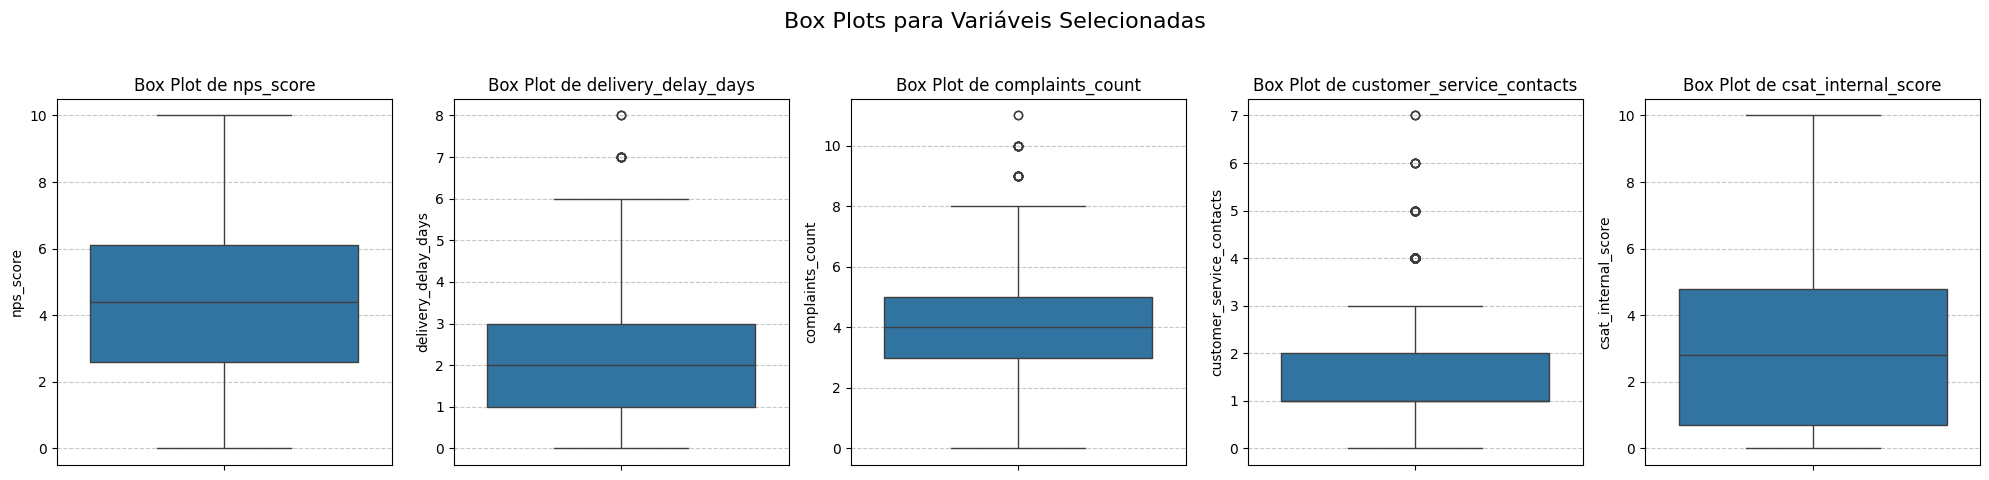

In [ ]:
import pandas as pd
df = pd.read_csv('desafio_nps_fase_1.csv')

import matplotlib.pyplot as plt
import seaborn as sns

# List of variables to plot
variables_to_plot = [
    'nps_score',
    'delivery_delay_days',
    'complaints_count',
    'customer_service_contacts',
    'csat_internal_score'
]

# Create a single figure with subplots for each Box Plot
fig, axes = plt.subplots(1, len(variables_to_plot), figsize=(20, 5)) # 1 row, N columns
fig.suptitle('Box Plots para Variáveis Selecionadas', fontsize=16)

for i, var in enumerate(variables_to_plot):
    # Box Plot
    sns.boxplot(y=df[var], ax=axes[i])
    axes[i].set_title(f'Box Plot de {var}')
    axes[i].set_ylabel(var)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Histogramas

O passo seguinte foi produzir histogramas para todas as variáveis, para detalhar melhor as tendências vistas no *Describe()*. Como *customer_id* e *order_id* são irrelevantes para a análise, vamos removê-las do dataset.

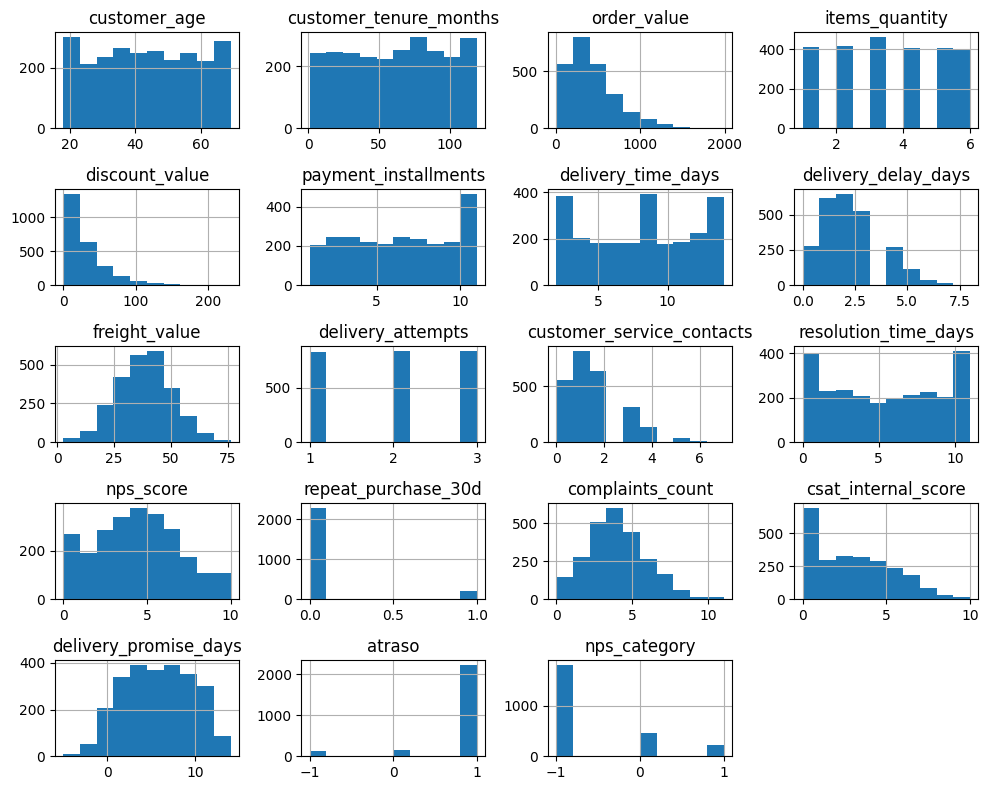

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import re # Importando o módulo de expressões regulares para extrair os nomes das colunas

# Gerar os histogramas para todas as colunas numéricas
df_hist = df.drop(['customer_id', 'order_id'], axis=1)
axes = df_hist.hist(bins=10, figsize=(10, 8))

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

As tendências vistas anteriormente no Boxplot das variáveis de NPS, CSAT, atrasos e reclamações aparecem novamente aqui com mais detalhes.

## Criação de Variável - *delivery_promise_days*

Resolvemos criar uma nova variavel *delivery_promise_days*, igual a: (*delivery_time* - *delivery_delay*). Se o tempo de entrega foi 10 dias e o atraso foi 2, então significa q foi prometido 8 dias pro cliente.






In [ ]:
df['delivery_promise_days'] = df['delivery_time_days'] - df['delivery_delay_days']

# Filtrar o DataFrame para remover as linhas onde delivery_promise_days é negativo
# df = df[df['delivery_promise_days'] >= 0].copy()

conditions = [
    df['delivery_promise_days'] < 0,   # -1 : atraso negativo (delay > time)
    df['delivery_promise_days'] == 0,  # 0: sem atraso (delay = 0)
    df['delivery_promise_days'] > 0    # 1: com atraso
]
choices = [-1, 0, 1]
df['atraso'] = np.select(conditions, choices, default=-9)
df['atraso'].value_counts()

,count
atraso,
1,2233
0,146
-1,121


Com isso encontramos casos de "atraso negativo", ou seja: *delivery_time* < *delivery_delay*, o que entendemos ser algum tipo de erro nos dados. Porém isso acontece em apenas 121 registros (4,8% da base), então resolvemos desconsiderá-los e seguir em frente.

## Avaliação das Categorias - NPS

Criamos a variável *nps_category* pra classificar o NPS. Seguindo a metodologia de NPS, os clientes são classificados como:

*   **Detrator** (até 5.9)
*   **Neutro** (notas entre 6.0 a 7.9)
*   **Promotor** (nota 8.0 ou superior)

In [ ]:
# NPS_category:
conditions = [
         df['nps_score'] <  6,                             # até 5.9: detrator
        (df['nps_score'] >= 6) & (df['nps_score'] <  8),   # de 6.0 a 7.9: neutro
         df['nps_score'] >= 8                              # 8.0 ou mais: promotor
]
# choices = ["detrator", "neutro", "promotor"]
choices   = [   -1     ,     0   ,      1    ]
df['nps_category'] = np.select(conditions, choices)

df['nps_category'].value_counts()

,count
nps_category,
-1,1817
0,465
1,218


<a id='#eda'></a>
#Análise Exploratória de Dados (E.D.A.) #

## Separação de Variáveis

Nos materiais sobre Vazamento de dados (*Data Leakage*), desaconselha-se a associção de variáveis "do passado" cronologicamente pra estudar uma variável "futura".

Deste modo, não é coerente inferir que o *NPS* do cliente (determinado ao final da etapa de compra) possa ser determinado/impactado, por exemplo, por uma nova compra realizada 30 dias depois(*repeat_purchase_30d*).

Como forma a isolar os estudos ao redor de variáveis conformes para cada momento,separamos em 3 momentos:
* Compra
* Entrega
* Pós-venda.

In [ ]:
# Definir as colunas para cada novo dataset (usando 'nps_score' como 'nps_value')
columns_eda_compra = [
    'customer_age', 'customer_region', 'customer_tenure_months', 'order_value',
    'items_quantity', 'discount_value', 'payment_installments',
    'freight_value', 'nps_score'
]

columns_eda_entrega = [
    'delivery_time_days', 'delivery_delay_days', 'delivery_attempts',
    'delivery_promise_days', 'nps_score', 'nps_category'
]

columns_eda_posvenda = [
    'customer_service_contacts', 'resolution_time_days', 'complaints_count',
    'csat_internal_score', 'nps_score', 'nps_category'
]

# Criar os novos datasets
eda_compra = df[columns_eda_compra].copy()
eda_entrega = df[columns_eda_entrega].copy()
eda_posvenda = df[columns_eda_posvenda].copy()

print("Datasets criados com sucesso:")
print("eda_compra:   " + str(eda_compra.shape))
print("eda_entrega:  " + str(eda_entrega.shape))
print("eda_posvenda: " + str(eda_posvenda.shape))

Datasets criados com sucesso:
eda_compra:   (2500, 9)
eda_entrega:  (2500, 6)
eda_posvenda: (2500, 6)


Fizemos uma matriz para cada momento, colorindo de vermelho ou azul as dispersões que apresentarem correlação maior:

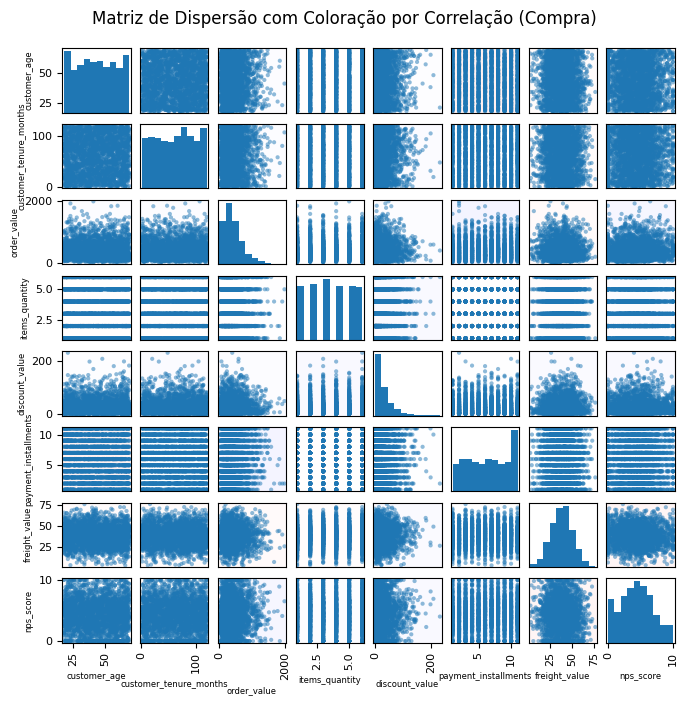

In [ ]:
def mat_corr(data, titl='Matriz de Dispersão com Coloração por Correlação',
             size_factor=1, label_fontsize=8, pad_factor=0.8, color=True):
    # Calculate the correlation matrix for data
    corr_mat = data.corr(numeric_only=True)

    # Create the scatter matrix plot
    sz = data.shape[1] * size_factor
    axs = pd.plotting.scatter_matrix(data, figsize=(sz, sz))

    # Get the list of numeric column names that are actually plotted
    numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

    # Iterate over the axes to set background colors based on correlation AND adjust label font size
    for i, ax_row in enumerate(axs):
        for j, ax in enumerate(ax_row):
            # Set font size for axis labels
            ax.xaxis.label.set_fontsize(label_fontsize)
            ax.yaxis.label.set_fontsize(label_fontsize)

            # Only process off-diagonal plots (scatter plots), skip histograms on the diagonal
            if i != j:
                col_x = numeric_cols[j]
                col_y = numeric_cols[i]

                # Get the correlation coefficient between these two columns
                correlation = corr_mat.loc[col_x, col_y]

                if color:
                  # Set background color based on correlation value
                  if correlation > 0: # Positive correlation (shades of blue)
                      # Scale from white (1,1,1) to blue (0,0,1) as correlation goes from 0 to 1
                      r = g = 1 - correlation
                      b = 1
                      ax.set_facecolor((r, g, b))
                  elif correlation < 0: # Negative correlation (shades of red)
                      # Scale from white (1,1,1) to red (1,0,0) as absolute correlation goes from 0 to 1
                      r = 1
                      g = b = 1 - abs(correlation)
                      ax.set_facecolor((r, g, b))
                  # For correlation == 0, the background remains default (white/transparent)

    plt.suptitle(titl, y=1.02) # Add a title
    plt.tight_layout(pad=pad_factor) # Adjust layout to prevent overlapping titles/labels
    plt.show()

### Análise - Compra

Notamos que nas variáveis da Compra existe pouca correlação com o NPS (os gráficos ficaram todos com fundo branco), possivelmente indicando que a experiência ***antes*** da entrega (preços, promoções, disponibilidade, catálogo de produtos, experiência do site etc) tem pouco efeito na insatisfação.

In [ ]:
std_title = 'Matriz de Dispersão com Coloração por Correlação'
mat_corr(eda_compra, titl = std_title + ' (Compra)', label_fontsize=6, size_factor = 0.75, pad_factor=0.25)

### Análise - Entrega

Já nas variáveis do momento Entrega, encontramos uma correlação relevante: *delivery_delay_days* impacta diretamente no *nps_category* (detrator/neutro/promotor).

Aqui também refutamos uma tese levantada no grupo, de que as tentativas de entrega influenciariam no atraso: temos casos de pedidos com grandes atrasos (5+ dias) e apenas 1 tentativa, e também temos casos de pedidos com 3 tentativas e nenhum atraso.

A correlação entre tentativas de entrega e dias de atraso é próxima de 0.

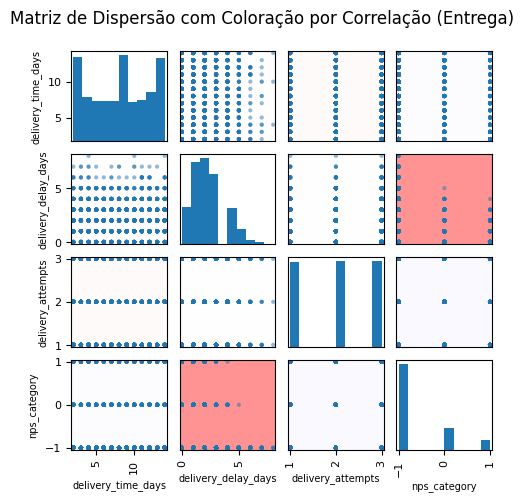

In [ ]:
# retirando a variável de tempo prometido
mat_corr(eda_entrega.drop(['delivery_promise_days','nps_score'], axis=1),
         titl = std_title + ' (Entrega)', size_factor=1.2, label_fontsize=7, pad_factor=0.5)

### Análise - Pós Venda

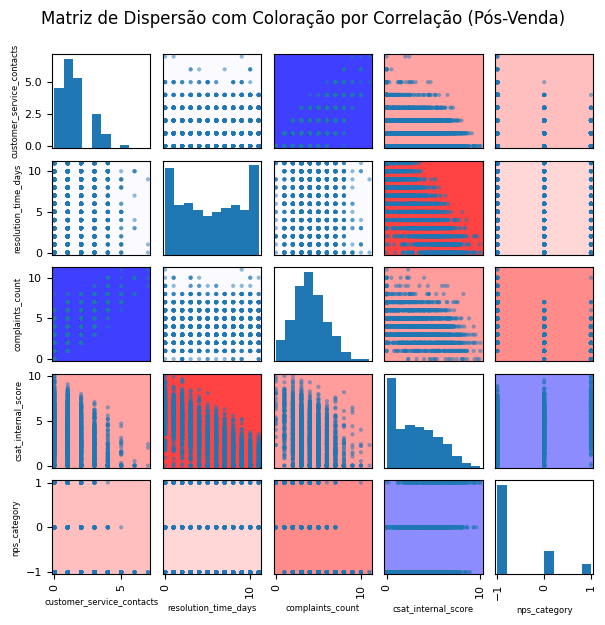

In [ ]:
mat_corr(eda_posvenda.drop(['nps_score'], axis=1),
         titl = std_title + ' (Pós-Venda)', size_factor=1.2, label_fontsize=6, pad_factor=0.5)

Já no Pós-Venda, todas as variáveis selecionadas têm impacto no NPS, principalmente 'customer_service_contacts', quando considerados os níveis mais altos (3+ contatos).

Mas o maior impacto no NPS vem de 'complaints_count': visualmente, praticamente todos os clientes com até 1 reclamação são Neutros ou Promotores. Mas a partir da segunda reclamação os Detratores começam a aparecer com força.

O tempo de resolução 'resolution_time_days' tem também alta correlação negativa com o 'CSAT_internal_score', mas mais fraca com o 'nps'score'.

Também percebemos uma correlação muito alta entre 'complaints_count' e 'customer_service_contacts', que veremos em detalhes mais à frente.

## Distribuição do NPS

Analisamos uma correlação mais direta entre o *nps_category* com essas variáveis que chamaram mais atenção:

- *complaints_count*
- *delivery_delay_days*
- *customer_service_contacts*

### Por Grupo de Reclamações ###

Percebemos que, com apenas 1 reclamação, os Promotores caíram de ≈70% para menos de 43%. (Queda de 27 p.p)

A partir da segunda reclamação, ficamos com pouco mais de 12% de Promotores (Nova queda, agora de 30 p.p), enquanto os Detratores passam a ser maioria, indo de apenas 3% para 57%.

Isso indica o "peso" relativo de não solucionar o problema do cliente ao primeiro contato.


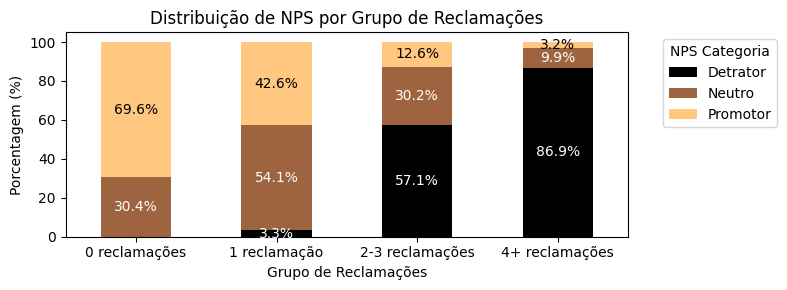

In [ ]:
# cria funcao para exibir tabelas de contingencia em grafico
def grafico_contingencia(ct, ttl, xlb, ylb='Porcentagem (%)'):
  # Plotting the stacked bar chart
  ax = ct.plot(kind='bar', stacked=True, figsize=(8, 3), colormap='copper')
  plt.title(ttl)
  plt.xlabel(xlb)
  plt.ylabel(ylb)
  plt.xticks(rotation=0, ha='center', fontsize=10)
  plt.legend(title='NPS Categoria', labels=['Detrator', 'Neutro', 'Promotor'],
             bbox_to_anchor=(1.05, 1), loc='upper left')

  # Add data labels
  for i, container in enumerate(ax.containers):
      labels = [f'{w:.1f}%' if w > 0 else '' for w in container.datavalues]
      # Determine label color based on category (Promotor is the 3rd container, index 2)
      label_color = 'white' if i != 2 else 'black'
      ax.bar_label(container, labels=labels, label_type='center',
                   fontsize=10, color=label_color)

  plt.tight_layout()
  plt.show()

# Create the 'complaints_group' column
bins = [-1, 0, 1, 3, df['complaints_count'].max()] # Bins for 0-1, 2-3, 4+
labels = ["0 reclamações", "1 reclamação", "2-3 reclamações", "4+ reclamações"]
df['complaints_group'] = pd.cut(df['complaints_count'], bins=bins,
                                labels=labels, right=True)

# Generate the cross-tabulation (contingency table)
# Normalize by 'index' to get percentages within each complaints_group
contingency_table     = pd.crosstab(df['complaints_group'],
                                    df['nps_category'], normalize='index') * 100
contingency_table_qtd = pd.crosstab(df['complaints_group'],
                                    df['nps_category'])

# Display the table, formatted for percentages
t = 'Distribuição de NPS por '
g = 'Grupo de Reclamações'
grafico_contingencia(contingency_table, ttl=t + g, xlb=g)

### Por Grupos de Atraso ###

Podemos ver que, ao primeiro dia de atraso, os Promotores caíram de 34% para menos de 15%. (Queda de 19 p.p)

Já no segundo dia de atraso os Promotores caíram para menos de 3% (mais 12 p.p de queda), indicando que o atraso também influencia negativamente no NPS, porém com menor peso que as reclamações.

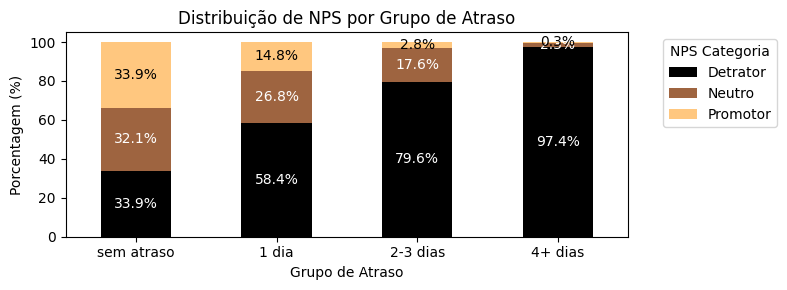

In [ ]:
# retirar casos de atraso negativo
df_sem_atraso = df[df['delivery_promise_days'] >= 0].copy()

# Create the 'delay_group' column
bins = [-1, 0, 1, 3, df_sem_atraso['delivery_delay_days'].max()]
labels = ["sem atraso", "1 dia", "2-3 dias", "4+ dias"]
df_sem_atraso['delay_group'] = pd.cut(df_sem_atraso['delivery_delay_days'],
                                      bins=bins, labels=labels, right=True)

# Generate the cross-tabulation (contingency table)
# Normalize by 'index' to get percentages within each delay_group
contingency_table     = pd.crosstab(df_sem_atraso['delay_group'],
                                    df_sem_atraso['nps_category'], normalize='index') * 100
contingency_table_qtd = pd.crosstab(df_sem_atraso['delay_group'],
                                    df_sem_atraso['nps_category'])

# Display the table, formatted for percentages
t = 'Distribuição de NPS por '
g = 'Grupo de Atraso'
grafico_contingencia(contingency_table, ttl=t + g, xlb=g)

### Por Grupo de Contatos ###

Notamos que quantidade de contatos também influencia fortemente no NPS, com uma Queda de 8 p.p no primeiro contato e mais 4,5 p.p a partir do segundo.

Neste cenário, iniciamos com pouquissímos Promotores (menos de 18%). No primeiro contato, já temos quase 70% de Detratores.

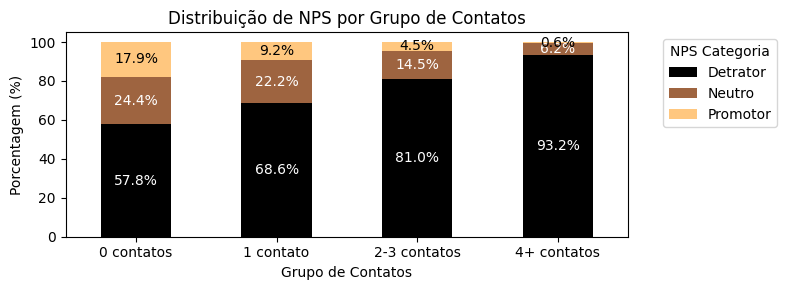

In [ ]:
# Create the 'contacts_group' column
bins = [-1, 0, 1, 3, df['customer_service_contacts'].max()] # Bins for 0-1, 2-3, 4+
labels = ["0 contatos", "1 contato", "2-3 contatos", "4+ contatos"]
df['contacts_group'] = pd.cut(df['customer_service_contacts'], bins=bins, labels=labels, right=True)

# Generate the cross-tabulation (contingency table)
# Normalize by 'index' to get percentages within each contacts_group
contingency_table = pd.crosstab(df['contacts_group'], df['nps_category'], normalize='index') * 100

# Display the table, formatted for percentages
t = 'Distribuição de NPS por '
g = 'Grupo de Contatos'
grafico_contingencia(contingency_table, ttl=t + g, xlb=g)

## Regressão Múltipla ##

Os resultados obtidos pelas análises, tanto na separação de etapas quanto na distribuição do NPS permitiu o entendimento claro da contribuição expressiva de algumas variáveis na definição do valor de NPS.

Como forma a tentar calcular a contribuição de cada variável, devido ao carater númerico, optamos por rodar uma regressão múltipla para identificar numericamente o impacto de cada uma dessas variáveis no NPS.

In [ ]:
import statsmodels.formula.api as smf

# Define a fórmula para a regressão múltipla
formula = 'nps_score ~ delivery_delay_days \
                     + complaints_count \
                     + resolution_time_days \
                     + customer_service_contacts'

# Realizar a regressão de Mínimos Quadrados Ordinários (OLS)
model_multiple = smf.ols(formula, data=df).fit()

# Imprimir o resumo da regressão
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     781.7
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:24:03   Log-Likelihood:                -4832.3
No. Observations:                2500   AIC:                             9675.
Df Residuals:                    2495   BIC:                             9704.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

A interpretação desse resultado é a seguinte:

$R^2$ = 0.556 significa que 55,6% da variação em *nps_score* pode ser explicada apenas por essas variáveis selecionadas. Um $R^2$ maior pode ser obtido com a inclusão de outras variáveis.
Mais a frente neste trabalho, calculamos o VIF de todas elas para avaliar possíveis influências de multicolinearidade.

O **Intercept** em 9.29 indica qual seria o NPS médio esperado num caso "ideal": sem atrasos, reclamações, contatos (e portanto sem demora na solução do contato). Um pedido em que tudo aconteceu conforme o planejado.

O coeficiente de -0.95 para *delivery_delay_days* nos traz um importante insight para o time de expedição/logística: cada dia perdido (atraso) significa a queda de ≈ 1 ponto no NPS médio do cliente. O p-valor que acompanha o coeficiente indica alto grau de confiança estatística nesse resultado.

Os coeficientes de *complaints_count* (-0.37) e *customer_service_contacts* (-0.32) indicam que essas variáveis também têm impacto no NPS.

Como insight para o time de atendimento, podemos afirmar a necessidade de resolver o problema na primeira vez, pois conforme obtido nas tabelas de contingência, a queda no primeiro contato/reclamação não é tão grande, mas no segundo é muito maior.

## VIF (Variance Inflation Factor)

O passo seguinte foi identificar se outras variáveis podem ter impacto parecido. Para isso vamos calcular o VIF (*Variance Inflation Factor*) delas e remover iterativamente as com VIF mais alto, para minimizar efeitos de multicolinearidade:

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Select only numeric columns for VIF calculation
df_numeric = df.select_dtypes(include=[np.number])

vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# Calculate VIF for each feature in the numeric DataFrame
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

# Sort the DataFrame by VIF values
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)

                      feature         VIF
0          delivery_time_days         inf
1         delivery_delay_days         inf
2       delivery_promise_days         inf
3                    order_id  269.053214
4         csat_internal_score   10.077601
5        resolution_time_days    6.569100
6                nps_category    5.468408
7                 customer_id    4.440333
8                   nps_score    4.270629
9   customer_service_contacts    4.040557
10           complaints_count    2.995566
11        repeat_purchase_30d    2.869384
12                     atraso    1.520407
13             items_quantity    1.011411
14                order_value    1.011089
15       payment_installments    1.010282
16               customer_age    1.008418
17             discount_value    1.006674
18          delivery_attempts    1.006411
19              freight_value    1.006408
20     customer_tenure_months    1.006032


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Vemos que as três variáveis relacionadas ao tempo (*delivery_time_days*, *delivery_delay_days* e *delivery_promise_days*, calculada a partir das outras duas) possuem VIF infinito, devido à alta correlação que elas possuem entre si. Removendo-as a calculada, poderemos observar a redução nos demais VIFs.

Aproveitamos para remover também *order_id* que apresentou VIF muito alto, assim como *customer_id*, com a qual possui correlação alta por serem ambas sequenciais. Retiramos também as variáveis *nps_score* e *nps_category*, assim como *repeat_purchase_30d* para evitar vazamento de dados.

Os valores de VIF baixaram consideravelmente, mas *complaints_count* ainda está bem alta, provavelmente devido à correlação com *customer_service_contacts*.

Durante a EDA inicial o grupo percebeu que essas duas variáveis tinham alguma conexão:

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF calculation
df_numeric = df.select_dtypes(include=[np.number]) \
               .drop(['delivery_promise_days', 'atraso',
                      'customer_id', 'order_id',
                      'nps_score', 'nps_category',
                      'repeat_purchase_30d'], axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# Calculate VIF for each feature in the numeric DataFrame
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

# Sort the DataFrame by VIF values
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)

                      feature        VIF
0            complaints_count  16.222547
1               freight_value  10.261731
2                customer_age   9.094410
3        resolution_time_days   7.606105
4   customer_service_contacts   7.575544
5         csat_internal_score   7.355197
6           delivery_attempts   6.851907
7          delivery_time_days   5.354825
8              items_quantity   5.136889
9         delivery_delay_days   5.119086
10       payment_installments   4.578576
11     customer_tenure_months   4.077429
12                order_value   3.232473
13             discount_value   2.045826


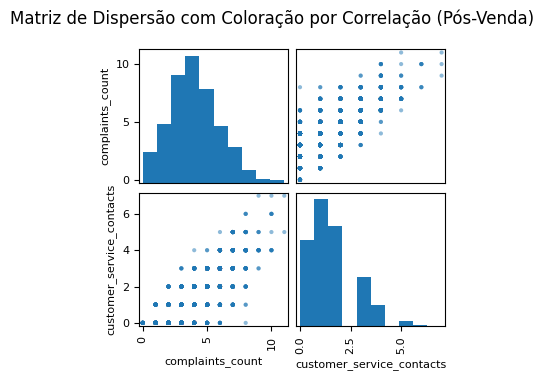

In [ ]:
df_complaints_contacts = df[['complaints_count', 'customer_service_contacts']]
mat_corr(df_complaints_contacts, titl = std_title + ' (Pós-Venda)',
         size_factor=1.8, label_fontsize=8, pad_factor=0.5, color=False)

Observamos que *complaints_count* é sempre maior ou igual a *customer_service_contacts*, nunca menor. Isso nos levou à hipótese de que uma variável poderia estar **contida** na outra, o que caracterizaria uma dupla contagem e exigiria remoção de uma delas na regressão.

Um ponto de atenção a destacar é que a maior das duas é *complaints_count*. Pensando na semântica dos dois termos, "contato" é um termo mais genérico,podendo englobar outros tipos de contato (informações, dúvidas,sugestões, etc.) além de reclamações. Estariam as colunas trocadas?

Assim, para testar a tese, realizamos o seguinte teste: calculamos o VIF duas vezes com o atual conjunto de variáveis em dois cenários:
* Retirando *complaints_count* e mantendo *customer_service_contacts*.
* Retirando *customer_service_contacts* e mantendo *complaints_count*.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_and_print_vif(dataframe, additional_cols_to_drop, title):
    # Select only numeric columns for VIF calculation
    # Drop base irrelevant/derived columns and then the additional ones
    base_cols_to_drop = ['delivery_promise_days', 'atraso',
                         'customer_id', 'order_id',
                         'nps_score', 'nps_category',
                         'repeat_purchase_30d']

    all_cols_to_drop = base_cols_to_drop + additional_cols_to_drop

    df_numeric_filtered = dataframe.select_dtypes(include=[np.number]) \
                                   .drop(all_cols_to_drop, axis=1, errors='ignore')

    if df_numeric_filtered.empty:
        print(f"\n--- VIF for: {title} ---")
        print("No numeric columns left for VIF calculation after dropping.")
        return

    vif_data = pd.DataFrame()
    vif_data["feature"] = df_numeric_filtered.columns

    # Calculate VIF for each feature in the numeric DataFrame
    # Handle cases where there's only one feature to avoid error with variance_inflation_factor
    if len(df_numeric_filtered.columns) > 1:
        vif_data["VIF"] = [variance_inflation_factor(df_numeric_filtered.values, i)
                           for i in range(len(df_numeric_filtered.columns))]
    else:
        # If only one feature, VIF is generally considered 1 (no multicollinearity)
        vif_data["VIF"] = 1.0

    # Sort the DataFrame by VIF values
    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

    print(f"\n--- VIF para: {title} ---")
    print(vif_data.to_string())

# Teste 1: Calculando VIF sem 'complaints_count'
calculate_and_print_vif(df, ['complaints_count'],
                        "Todas as Variáveis (excluindo 'complaints_count')")

# Teste 2: Calculando VIF sem 'customer_service_contacts'
calculate_and_print_vif(df, ['customer_service_contacts'],
                        "Todas as Variáveis (excluindo 'customer_service_contacts')")


--- VIF para: Todas as Variáveis (excluindo 'complaints_count') ---
                      feature        VIF
0               freight_value  10.233623
1                customer_age   9.092729
2        resolution_time_days   7.370212
3         csat_internal_score   7.123860
4           delivery_attempts   6.843290
5          delivery_time_days   5.354457
6              items_quantity   5.092727
7        payment_installments   4.578554
8         delivery_delay_days   4.307536
9      customer_tenure_months   4.075105
10                order_value   3.231173
11  customer_service_contacts   3.081678
12             discount_value   2.045751

--- VIF para: Todas as Variáveis (excluindo 'customer_service_contacts') ---
                   feature        VIF
0            freight_value  10.111014
1             customer_age   8.904158
2     resolution_time_days   6.819361
3        delivery_attempts   6.804439
4         complaints_count   6.599219
5      csat_internal_score   6.101228
6       deliv

Quando excluímos *complaints_count*, o VIF de *customer_service_contacts* baixou significativamente, de 7.63 para 3.096. Isso indica redução de multicolinearidade.

E quando excluímos *customer_service_contacts*, o VIF de *complaints_count* também baixou consideravelmente, de 16.678 para 6.767. Porém ainda mantendo alguma multicolinearidade com outras variáveis.

Concluímos que ambas as variáveis reduzem o VIF quando excluídas individualmente, mas *customer_service_contacts* (VIF 3.08) ganhou de *complaints_count* (VIF 6.59) e portanto, será mantida no dataset para os próximos passos.

Ambos os testes também mostram que *freight_value* e *customer_age* continuam a apresentar VIFs elevados, indicando que a multicolinearidade não se restringe apenas às variáveis de contato/reclamação.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns for VIF calculation
df_numeric = df.select_dtypes(include=[np.number]) \
               .drop(['delivery_promise_days', 'atraso',
                      'customer_id', 'order_id',
                      'complaints_count',
                      # 'customer_service_contacts',
                      # 'freight_value', 'customer_age',
                      'nps_score', 'nps_category',
                      'repeat_purchase_30d'], axis=1)

vif_data = pd.DataFrame()
vif_data["feature"] = df_numeric.columns

# Calculate VIF for each feature in the numeric DataFrame
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

# Sort the DataFrame by VIF values
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)

                      feature        VIF
0               freight_value  10.233623
1                customer_age   9.092729
2        resolution_time_days   7.370212
3         csat_internal_score   7.123860
4           delivery_attempts   6.843290
5          delivery_time_days   5.354457
6              items_quantity   5.092727
7        payment_installments   4.578554
8         delivery_delay_days   4.307536
9      customer_tenure_months   4.075105
10                order_value   3.231173
11  customer_service_contacts   3.081678
12             discount_value   2.045751


Removemos também *customer_age* e *freight_value*, e os VIFs das variáveis ficaram todos relativamente baixos, a ponto de podermos refazer a regressão agora com todas as variáveis.

In [ ]:
import statsmodels.formula.api as smf

# Define a fórmula para a regressão múltipla
formula = 'nps_score ~  customer_tenure_months    \
                      + discount_value            \
                      + items_quantity            \
                      + order_value               \
                      + payment_installments      \
                      + delivery_delay_days       \
                      + delivery_time_days        \
                      + customer_service_contacts \
                      + delivery_attempts         \
                      + resolution_time_days      \
                      + freight_value             \
                      + customer_age              \
                      + csat_internal_score       \
                      '

# Realizar a regressão de Mínimos Quadrados Ordinários (OLS)
model_multiple = smf.ols(formula, data=df).fit()

# Imprimir o resumo da regressão
print(model_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:              nps_score   R-squared:                       0.530
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     255.3
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:09:59   Log-Likelihood:                -4903.4
No. Observations:                2500   AIC:                             9831.
Df Residuals:                    2488   BIC:                             9901.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Vimos que, apesar do cuidado na seleção das variáveis, um modelo mais refinado não resultou no aumento do $R^2$, portanto optaremos pelo modelo anterior que usa apenas 4 variáveis: *delivery_delay_days*, *complaints_count*, *resolution_time_days* e *customer_service_contacts*.

<a id='#results'></a>
# Comunicação dos Resultados


<!--- gerado por gepeto-->

## Pontos de Melhoria para o Negócio

- **Reduzir drasticamente os atrasos nas entregas.** Com 89% dos pedidos entregues com algum atraso, o maior ganho de NPS estará em atacar a pontualidade logística. Revisão de SLAs com transportadoras, melhoria de previsão de prazo e comunicação proativa ao cliente são caminhos imediatos.

- **Investir em resolução no primeiro contato (FCR — First Call Resolution).** A queda mais acentuada no NPS ocorre na transição de 1 para 2 reclamações. Treinar o time de atendimento para resolver o problema completamente na primeira interação tem potencial de impacto muito alto.

- **Reduzir o tempo de resolução de chamados.** O `resolution_time_days` impacta negativamente tanto o CSAT quanto o NPS. Processos mais ágeis de triagem e escalonamento de chamados devem ser priorizados.

- **Monitorar e tratar os casos de dados inconsistentes.** Os 4,8% de registros com "atraso negativo" (`delivery_delay_days > delivery_time_days`) indicam erros de registro ou integração entre sistemas. Endereçar isso melhora a qualidade dos dados para análises futuras.

## Principais Insights

- **O NPS geral é estruturalmente baixo.** Mais de 75% dos pedidos registraram NPS abaixo de 6,1, o que classifica a vasta maioria dos clientes como detratores. Esse padrão não é pontual — é sistêmico e reflete falhas recorrentes na operação.

- **A experiência de compra (pré-entrega) tem pouco impacto no NPS.** Variáveis como valor do pedido, quantidade de itens, descontos, frete e número de parcelas não apresentaram correlação relevante com o NPS. Isso indica que o problema não está na vitrine ou no checkout, mas na execução pós-compra.

- **O atraso na entrega é o principal gatilho de insatisfação na etapa logística.** Apenas 11% dos pedidos foram entregues no prazo. Cada dia adicional de atraso representa uma queda média de aproximadamente 1 ponto no NPS (coeficiente de regressão: −0,95). Com 1 dia de atraso, a proporção de promotores já cai de 34% para menos de 15%; com 2 ou mais dias, cai para menos de 3%.

- **Reclamações são o fator de maior impacto isolado no NPS.** Com zero reclamações, cerca de 70% dos clientes são promotores. Com apenas 1 reclamação, essa proporção cai para 43% (−27 p.p.). A partir da segunda reclamação, os detratores passam a ser maioria (57%), enquanto os promotores recuam para apenas 12%. Isso evidencia que a resolução no primeiro contato é determinante.

- **O volume de contatos com o atendimento agrava progressivamente a insatisfação.** Mesmo clientes que precisaram de apenas 1 contato já apresentam quase 70% de detratores. A partir do segundo contato, o NPS piora ainda mais, reforçando a necessidade de resolutividade imediata.

- **As variáveis de Pós-Venda explicam 55,6% da variação do NPS** no modelo de regressão múltipla com apenas 4 preditores (`delivery_delay_days`, `complaints_count`, `resolution_time_days`, `customer_service_contacts`), evidenciando que a experiência pós-compra é o principal campo de atuação para melhorar o indicador.

- **O "caminho feliz" (sem atraso, sem reclamações, sem contatos) é raro, mas confirma o potencial de NPS alto** quando a operação funciona conforme planejado — o intercepto da regressão aponta NPS médio de 9,29 nesse cenário ideal.

- **Existe alta correlação entre `complaints_count` e `customer_service_contacts`**, sugerindo que as variáveis podem ser parcialmente redundantes ou que os campos foram preenchidos de forma invertida no sistema de origem — ponto que merece investigação junto à área de dados.


## Possibilidades para Aprofundamento da Análise

- **Modelagem preditiva do NPS.** Com as variáveis identificadas nesta EDA, é possível construir modelos supervisionados (regressão regularizada, gradient boosting, redes neurais) com maior poder explicativo, permitindo prever o NPS de um pedido ainda durante sua execução — antes da pesquisa ser aplicada.

- **Segmentação de clientes por perfil de risco.** Cruzar variáveis como `customer_tenure_months`, `customer_region` e histórico de reclamações pode revelar perfis de clientes com maior probabilidade de se tornar detratores, permitindo ações preventivas personalizadas.

- **Análise de causalidade entre reclamações e contatos.** A ambiguidade identificada entre `complaints_count` e `customer_service_contacts` merece investigação aprofundada: são contatos que geram reclamações, ou reclamações que multiplicam contatos? Entender a sequência causal é essencial para alocar esforços corretamente.

- **Análise temporal (time series).** Investigar se os atrasos e reclamações se concentram em períodos sazonais (datas comemorativas, picos de demanda) pode orientar o planejamento de capacidade operacional.

- **Inclusão de variáveis de categoria de produto e transportadora.** Caso esses dados estejam disponíveis, seria possível identificar quais categorias ou parceiros logísticos concentram os maiores volumes de atraso e reclamação, permitindo ações focadas.

- **Análise de texto (NLP) sobre os chamados de atendimento.** Se houver registros textuais dos atendimentos, técnicas de processamento de linguagem natural poderiam revelar os temas mais recorrentes nas reclamações e oportunidades de automação ou melhoria de processos.